In [1]:
import jax
import jax.numpy as jnp

import hodel
import matplotlib.pyplot as plt
from helper import get_triplets, animate_rod

jax.config.update("jax_enable_x64", True)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 8,
        "axes.labelsize": 8,
        "legend.fontsize": 7,
        "figure.dpi": 300,
    }
)

data = jnp.load("data/ribbon_data.npz")

### Benchmarks

In [2]:
# Print max HoDEL Error
test = jnp.load("data/benchmarks_hodel.npz", allow_pickle=True)
mean = jnp.mean(test["batch_errs"],axis=1)
rmse = jnp.sqrt(jnp.mean(test["batch_errs"]**2,axis=1))
max_error = jnp.max(test["batch_errs"], axis=1)
print(f"NaNs: {jnp.count_nonzero(jnp.isnan(test["batch_errs"]))}/{test["batch_errs"].size}")
print(f"MAE: {jnp.median(mean):.3f}±{jnp.std(mean):.3f}")
print(f"RMSE: {jnp.median(rmse):.3f}±{jnp.std(rmse):.3f}")
print(f"Max Error: {jnp.median(max_error):.3f}±{jnp.std(max_error):.3f}")

NaNs: 0/420
MAE: 0.176±0.009
RMSE: 0.286±0.015
Max Error: 0.723±0.038


In [4]:
# Print max PINN Error
test = jnp.load("data/benchmarks_pinn.npz", allow_pickle=True)
mean = jnp.mean(test["batch_errs"],axis=1)
rmse = jnp.sqrt(jnp.mean(test["batch_errs"]**2,axis=1))
max_error = jnp.max(test["batch_errs"], axis=1)
print(f"NaNs: {jnp.count_nonzero(jnp.isnan(test["batch_errs"]))}/{test["batch_errs"].size}")
print(f"MAE: {jnp.median(mean):.3f}±{jnp.std(mean):.3f}")
print(f"RMSE: {jnp.median(rmse):.3f}±{jnp.std(rmse):.3f}")
print(f"Max Error: {jnp.median(max_error):.3f}±{jnp.std(max_error):.3f}")

NaNs: 0/420
MAE: 0.278±0.029
RMSE: 0.547±0.068
Max Error: 1.544±0.250


In [3]:
# Print max NODE Error
test = jnp.load("data/benchmarks_node.npz", allow_pickle=True)
mean = jnp.mean(test["batch_errs"],axis=1)
rmse = jnp.sqrt(jnp.mean(test["batch_errs"]**2,axis=1))
max_error = jnp.max(test["batch_errs"], axis=1)
print(f"NaNs: {jnp.count_nonzero(jnp.isnan(test["batch_errs"]))}/{test["batch_errs"].size}")
print(f"MAE: {jnp.median(mean):.3f}±{jnp.std(mean):.3f}")
print(f"RMSE: {jnp.median(rmse):.3f}±{jnp.std(rmse):.3f}")
print(f"Max Error: {jnp.median(max_error):.3f}±{jnp.std(max_error):.3f}")

NaNs: 0/420
MAE: 0.293±0.006
RMSE: 0.578±0.015
Max Error: 1.668±0.062


In [5]:
# Get DER Error
sim, state0, xf0, _, get_aux = get_triplets(der=True)
lambdas = jnp.linspace(0, 1.0, 11)

@jax.jit
def fn(params_, batch_xf_stars, batch_aux):
    return jax.vmap(
        lambda xf_stars_, aux_: sim.loss(
            lambdas,
            xf0,
            xf_stars_,
            params_,
            aux_,
            state0,
            config=hodel.SolverConfig(isteps=200),
        )
    )(batch_xf_stars, batch_aux)


data = jnp.load("data/ribbon_data.npz")
test_xf_stars = data["test_xf_stars"]
test_aux = jax.vmap(get_aux)(data["test_aux"])
err0 = fn(None, test_xf_stars, test_aux)    # No params for DER

mean = jnp.nanmean(err0)
rmse = jnp.sqrt(jnp.nanmean(err0**2))
max_error = jnp.nanmax(err0)
print(f"NaNs: {jnp.count_nonzero(jnp.isnan(err0))}/{len(err0)}")
print(f"MAE: {mean:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Max Error: {max_error:.3f}")

NaNs: 0/14
MAE: 0.293
RMSE: 0.574
Max Error: 1.644


### Ablation $\lambda$ and Arch

In [ ]:
data = jnp.load("data/ribbon_data.npz")
test_xf_stars = data["test_xf_stars"]
safe_limit = jnp.max(jnp.abs(test_xf_stars)) * 10
sim, state0, xf0, _, get_aux = get_triplets(der=True)


def get_stability_metrics(lambdas, aux):
    sol = sim.solve(lambdas, xf0, None, aux, state0)
    is_finite = jnp.all(jnp.isfinite(sol), axis=-1)
    is_safe = jnp.all(jnp.abs(sol) < safe_limit, axis=-1)
    valid_mask = is_finite & is_safe
    first_failure_idx = jnp.where(
        ~valid_mask, jnp.arange(len(valid_mask)), len(valid_mask)
    ).min()
    num_intervals = len(lambdas) - 1
    successful_intervals = jnp.maximum(first_failure_idx - 1, 0)
    completion_fraction = jnp.where(
        num_intervals > 0, successful_intervals / num_intervals, 0.0
    )
    return completion_fraction, first_failure_idx


tsteps = jnp.arange(1, 1500, 50)
tsteps = jnp.where(tsteps < 2, 2, tsteps)  # at least 0.0 and 1.0
batch_aux = jax.vmap(get_aux)(data["test_aux"])
results = []
for n in tsteps:
    current_lambdas = jnp.linspace(0.0, 1.0, n)
    frac, _ = jax.vmap(get_stability_metrics, (None, 0))(current_lambdas, batch_aux)
    results.append(frac)
    med_frac = jnp.mean(frac)
    # print(f"Steps: {n:4d} | Mean Completion: {med_frac:.2%}")
jnp.savez("ablation_lambda.npz", precentage=jnp.asarray(results) * 100)


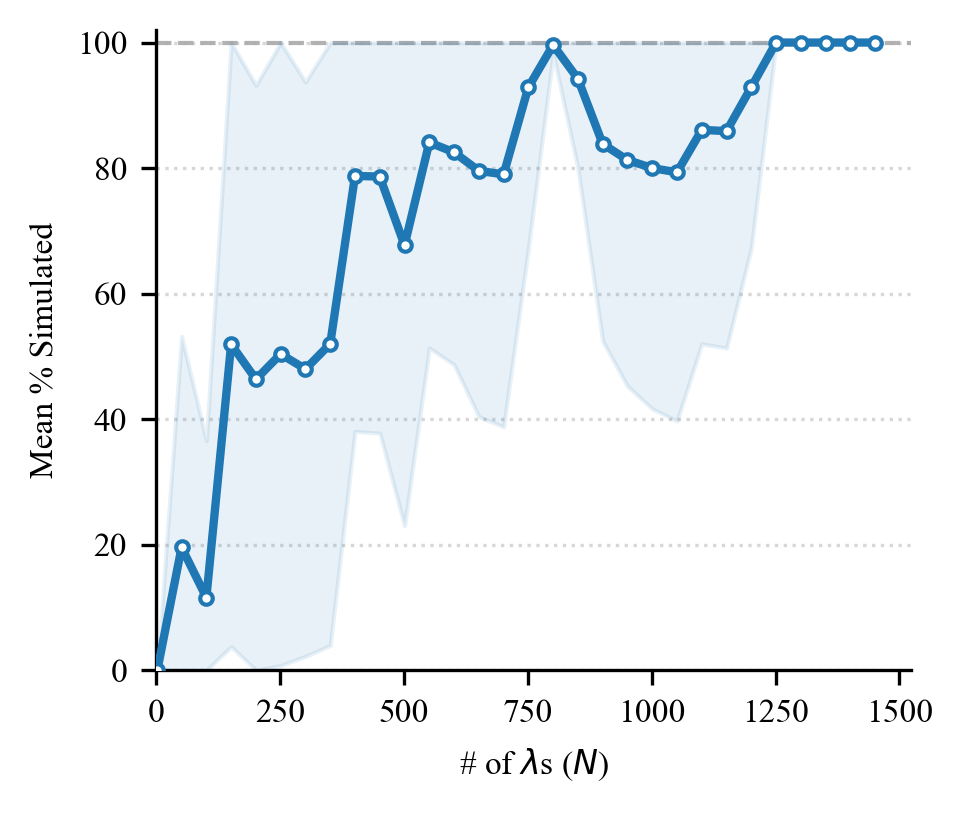

In [38]:
results_lambda = jnp.load("data/ablation_lambda.npz")
sim_precentage = results_lambda["precentage"]

# Calculate mean and std
mean_results = jnp.mean(sim_precentage, axis=1)
std_results = jnp.std(sim_precentage, axis=1)

# Clip the bounds so they don't exceed 0 or 1
lower_bound = jnp.clip(mean_results - std_results, 0.0, 100.0)
upper_bound = jnp.clip(mean_results + std_results, 0.0, 100.0)

fig, ax = plt.subplots(figsize=(3.25, 2.75), dpi=300)

# 1. Plot the Mean
ax.plot(tsteps, mean_results, label='Mean Completion', 
        color='#1f77b4', linewidth=2, marker='o', 
        markersize=3, markerfacecolor='white', zorder=3)

# 2. Plot the Shaded Region with clipped bounds
ax.fill_between(tsteps, lower_bound, upper_bound, 
                color='#1f77b4', alpha=0.1, zorder=2)

# 3. Add the 100% Target line
ax.axhline(y=100.0, color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=1)

# Set the limits strictly
ax.set_ylim(0, 102) # 1.05 gives just a tiny bit of breathing room above the line
ax.set_xlim(left=0)

# Standard ICML styling
ax.set_xlabel(r'# of $\lambda$s ($N$)')
ax.set_ylabel('Mean % Simulated')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

#plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("3d_ribbon_lambdas_ablation.pdf", bbox_inches="tight")
plt.show()

In [ ]:
data = jnp.load("data/ribbon_data.npz")
test_xf_stars = data["test_xf_stars"]
safe_limit = 1000
_, state0, xf0, _, get_aux = get_triplets(der=True)


def get_stability_metrics2(aux, lambdas, sim, params):
    sol = sim.solve(lambdas, xf0, params, aux, state0)
    is_finite = jnp.all(jnp.isfinite(sol), axis=-1)
    is_safe = jnp.all(jnp.abs(sol) < safe_limit, axis=-1)
    valid_mask = is_finite & is_safe
    first_failure_idx = jnp.where(
        ~valid_mask, jnp.arange(len(valid_mask)), len(valid_mask)
    ).min()
    num_intervals = len(lambdas) - 1
    successful_intervals = jnp.maximum(first_failure_idx - 1, 0)
    completion_fraction = jnp.where(
        num_intervals > 0, successful_intervals / num_intervals, 0.0
    )
    return completion_fraction, first_failure_idx


lambdas = jnp.linspace(0.0, 1.0, 1250)
batch_aux = jax.vmap(get_aux)(data["test_aux"])

# NN
results = []
for i in range(30):
    key = jax.random.PRNGKey(i)
    sim, state0, xf0, params, get_aux = get_triplets(icnn=False, from_x=True) # Change for different architectures
    frac, _ = jax.vmap(get_stability_metrics2, (0, None, None, None))(
        batch_aux, lambdas, sim, params
    )
    #print(frac)
    results.append(frac)
results = jnp.asarray(results)